<heading style="color: black; font-size: 29px; line-height: 1.4; font-family: 'Times New Roman', Times, serif;">
Example 1: Introduction<br>
<div style="color: black; font-size: 18px; line-height: 1.4; font-family: 'Times New Roman', Times, serif;">
This notebook serves as an introduction to the Tencyl package and demonstrates how to calculate the scattering cross section of a solid infinite cylinder.
</div>

<table>
<tr>
<td width="60%">

<div style="color: black; font-size: 18px; line-height: 1.4; font-family: 'Times New Roman', Times, serif;">
The coordinate system we use is depicted in the accompanying figure. <br><br>
In later examples we will examine the scattering of a larger cylinder with smaller cylinders placed within, to distinguish between the two we will refer to the larger cylinder as the fibre.<br><br>
To begin we import torch and the tencyl package, define our constants for the incoming plane wave and cylinder structure as torch tensors. <br><br>
These constants are passed to the Fibre class, which constructs and stores the relevant scattering matrix.<br><br>

</div>

</td>
<td width="40%">

<img src="./fibre_coordinate_system.png" width="300">

</td>
</tr>
</table>

In [ ]:
import torch
import tencyl

tencyl.scat.set_global_truncation(1.0)                          #Can adjust global multiplier for bessel function truncation

# Incident Plane Wave
lam0    = torch.tensor(0.3          ,dtype=torch.float64)       #incident vacuum wavelength (dimensionless)
k0      = 2*torch.pi/lam0                                       #incident vacuum wavenumber
phi     = torch.tensor(0.4*torch.pi ,dtype=torch.float64)
theta   = torch.tensor(0.2*torch.pi ,dtype=torch.float64)
delta   = torch.tensor(0.1*torch.pi ,dtype=torch.float64)       #polarisation

# Structure
fibre_n = torch.tensor(1.5+0.01j    ,dtype=torch.complex128)    #fibre refractive index
fibre_a = torch.tensor(2.0          ,dtype=torch.float64)       #fibre radius

fibre_1=tencyl.fibre.Fibre(k0,phi,fibre_n,fibre_a)              #5th optional argument allows you to specify truncation, 
                                                                #otherwise it is calculated for you


<div style="color: black; font-size: 18px; line-height: 1.4; font-family: 'Times New Roman', Times, serif;">
A new instance of the Fibre class must be created for each pair of k0 and phi, different theta and delta values can reuse the same fibre since changing them does not alter the fibre's scattering matrix.
A range of metrics and figures of merit are available in the tencyl.metric file, here we evaluate the scattering and extinction cross section.
</div>
 

In [3]:
sigma_sca,sigma_ext=tencyl.metrics.cross_sections(fibre_1,theta,delta)
print("Scattering cross section",sigma_sca)
print("Extinction cross section",sigma_ext)

Scattering cross section tensor(5.1849)
Extinction cross section tensor(8.2664)


<div style="color: black; font-size: 18px; line-height: 1.4; font-family: 'Times New Roman', Times, serif;">
You can also input a vector of theta and/or delta values and these will be solved in parallel.
</div>

In [4]:
delta_vals=torch.linspace(0.0*torch.pi,0.5*torch.pi,9)
sigma_sca,sigma_ext=tencyl.metrics.cross_sections(fibre_1,theta,delta_vals)
print("Scattering cross section",sigma_sca)
print("Extinction cross section",sigma_ext)

Scattering cross section tensor([5.2082, 5.1989, 5.1725, 5.1329, 5.0862, 5.0395, 4.9999, 4.9734, 4.9641])
Extinction cross section tensor([8.2684, 8.2676, 8.2653, 8.2619, 8.2579, 8.2539, 8.2505, 8.2482, 8.2474])


<div style="color: black; font-size: 18px; line-height: 1.4; font-family: 'Times New Roman', Times, serif;">
We can also examine the fields outside the fibre.
</div>

In [ ]:
grid_pts=100
x=torch.linspace(-4,4,grid_pts)
y=torch.linspace(-3,3,grid_pts)
E,K=tencyl.metrics.external_field(fibre_1,theta,delta,x,y,grid_pts)


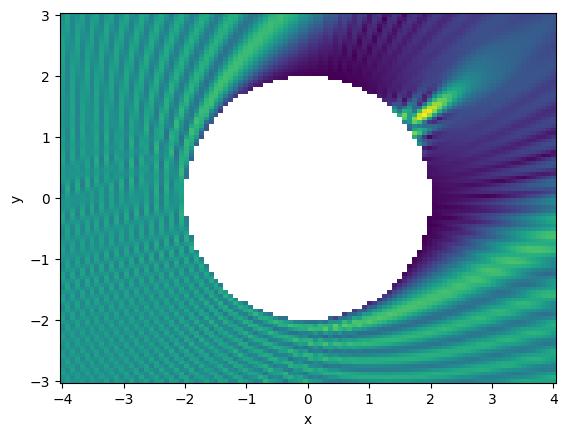

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

pcm = ax.pcolormesh(x, y, E.abs(), shading="auto")
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_aspect("equal", adjustable="box")
plt.show()
